# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [144]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.tokenize import PunktSentenceTokenizer
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
train_fname = 'tweet_sentiment_train.csv.zip'
raw_df = pd.read_csv(train_fname)

In [3]:
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
raw_df.shape

(27481, 4)

In [5]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [6]:
raw_df.isnull().sum()

textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

In [7]:
raw_df = raw_df.dropna()

In [8]:
raw_df.isnull().sum()

textID           0
text             0
selected_text    0
sentiment        0
dtype: int64

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [9]:
raw_df.sentiment.value_counts(normalize=True)

sentiment
neutral     0.404549
positive    0.312300
negative    0.283151
Name: proportion, dtype: float64

<Axes: >

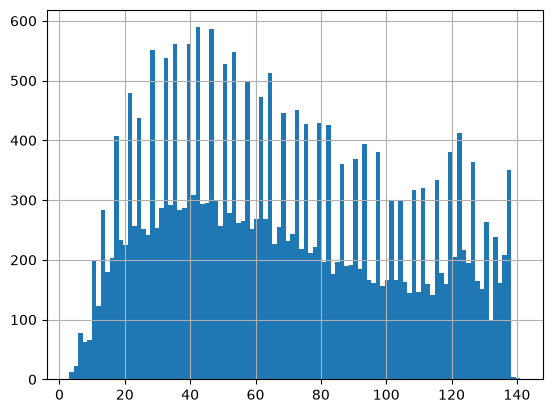

In [18]:
raw_df.text.astype(str).str.len().hist(bins=100)

В розподілі тагрету немає сильного дисбалансу. Найбільше текстів приблизно на 40-45 символів.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [39]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ivashuty\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ivashuty\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [38]:
english_stopwords = stopwords.words('english')
stemmer = SnowballStemmer(language='english')

In [71]:
def preprocess_text(text):
    if not isinstance(text,str):
        text = "" if text is None else str(text)

    text = text.lower()
        
    tokens = word_tokenize(text)

    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in english_stopwords and len(t)>1]
    tokens = [stemmer.stem(t) if t.isalpha() else t for t in tokens]
    return " ".join(tokens)

In [72]:
raw_df['text_clean'] = raw_df['text'].apply(preprocess_text)

In [73]:
raw_df

,textID,text,selected_text,sentiment,text_clean
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,respond go
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,sooo sad miss san diego
2,088c60f138,my boss is bullying me...,bullying me,negative,boss bulli
3,9642c003ef,what interview! leave me alone,leave me alone,negative,interview leav alon
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,son put releas alreadi bought
...,...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative,wish could come see denver husband lost job af...
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative,wonder rake client made clear forc dev learn n...
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive,yay good enjoy break probabl need hectic weeke...
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive,worth


In [74]:
vectorizer = CountVectorizer(lowercase=False,
                             token_pattern=r"(?u)\b\w+\b",
                             max_features=5000)

In [75]:
X_bow = vectorizer.fit_transform(raw_df['text_clean'])

In [76]:
print(X_bow.shape)

(27480, 5000)


In [77]:
print(vectorizer.get_feature_names_out()[50:60])

['advic' 'affect' 'afford' 'afraid' 'africa' 'afternoon' 'afterward' 'age'
 'agenc' 'agent']


In [78]:
raw_df[['text','text_clean']].head()

,text,text_clean
0,"I`d have responded, if I were going",respond go
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego
2,my boss is bullying me...,boss bulli
3,what interview! leave me alone,interview leav alon
4,"Sons of ****, why couldn`t they put them on t...",son put releas alreadi bought


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [83]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, raw_df.sentiment,
                                                            test_size=0.3, random_state=42)

In [88]:
X_train_bow.shape, y_train.shape

((19236, 5000), (19236,))

In [89]:
X_test_bow.shape, y_test.shape

((8244, 5000), (8244,))

**Logistic Regression**

In [91]:
model = LogisticRegression(max_iter=1000, solver='sag')
model.fit(X_train_bow, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'sag'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of t

In [104]:
test_preds = model.predict(X_test_bow)

In [106]:
pd.Series(test_preds).value_counts()

neutral     3781
positive    2444
negative    2019
Name: count, dtype: int64

In [107]:
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

    negative       0.70      0.60      0.64      2356
     neutral       0.63      0.71      0.67      3343
    positive       0.74      0.71      0.73      2545

    accuracy                           0.68      8244
   macro avg       0.69      0.67      0.68      8244
weighted avg       0.68      0.68      0.68      8244



**Decision Tree**

In [109]:
tree = DecisionTreeClassifier(
    max_depth = 20,
    min_samples_leaf = 5,
    random_state = 42)


tree.fit(X_train_bow, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [110]:
tree_preds = tree.predict(X_test_bow)

In [111]:
print(classification_report(y_test, tree_preds))

              precision    recall  f1-score   support

    negative       0.79      0.31      0.44      2356
     neutral       0.53      0.87      0.66      3343
    positive       0.78      0.57      0.66      2545

    accuracy                           0.62      8244
   macro avg       0.70      0.58      0.59      8244
weighted avg       0.68      0.62      0.60      8244



**XGBoost**

In [127]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [157]:
xgb = XGBClassifier(
    objective="multi:softprob",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=20,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [158]:
xgb.fit(X_train_bow, y_train_enc)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [159]:
xgb_preds = le.inverse_transform(xgb.predict(X_test_bow))

In [160]:
print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

    negative       0.76      0.59      0.66      2356
     neutral       0.66      0.77      0.71      3343
    positive       0.76      0.76      0.76      2545

    accuracy                           0.71      8244
   macro avg       0.73      0.71      0.71      8244
weighted avg       0.72      0.71      0.71      8244



**Baseline**

In [136]:
#majority
dummy_maj = DummyClassifier(strategy='most_frequent')
dummy_maj.fit(X_train_bow, y_train)
mai_preds = dummy_maj.predict(X_test_bow)

#Stratified
dummy_str = DummyClassifier(strategy='stratified', random_state=42)
dummy_str.fit(X_train_bow, y_train)
srt_preds = dummy_str.predict(X_test_bow)

print(classification_report(y_test, mai_preds))
print(classification_report(y_test, srt_preds))

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00      2356
     neutral       0.41      1.00      0.58      3343
    positive       0.00      0.00      0.00      2545

    accuracy                           0.41      8244
   macro avg       0.14      0.33      0.19      8244
weighted avg       0.16      0.41      0.23      8244

              precision    recall  f1-score   support

    negative       0.29      0.28      0.28      2356
     neutral       0.39      0.39      0.39      3343
    positive       0.31      0.33      0.32      2545

    accuracy                           0.34      8244
   macro avg       0.33      0.33      0.33      8244
weighted avg       0.34      0.34      0.34      8244



C:\Users\ivashuty\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ivashuty\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ivashuty\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

Найкраще передбачає XGBClassifier. F1-macro = 0.71, що набагато більше ніж baseline.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [140]:
feature_names = vectorizer.get_feature_names_out()
feature_importance = xgb.feature_importances_

In [141]:
imp_df = pd.DataFrame({
    'token': feature_names,
    'importance': feature_importance
}).sort_values('importance',ascending=False)

In [142]:
imp_df.head(20)

,token,importance
1960,happi,0.004918
4364,thank,0.004480
125,amaz,0.003679
273,awesom,0.003282
1870,great,0.003054
1979,hate,0.002964
2983,nice,0.002905
3709,sad,0.002885
4216,suck,0.002771
1498,fail,0.002710


In [143]:
imp_df.tail(20)

,token,importance
2041,hhrs,0.0
2044,hiccup,0.0
2045,hid,0.0
2048,higher,0.0
2049,highlight,0.0
2052,hii,0.0
2075,hobbi,0.0
2053,hiii,0.0
2054,hike,0.0
2057,himym,0.0


Вважаю обрані слова логічними.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [146]:
tfidf_vectorizer = TfidfVectorizer(lowercase=False,
                             token_pattern=r"(?u)\b\w+\b",
    # Регулярний вираз для виділення токенів:
    # (?u) — використовувати Unicode-режим, тому \w підтримує українські та інші Unicode-символи;
    # \b   — межа слова;
    # \w+  — один або більше символів слова: літери, цифри або символ `_`;
    # \b   — кінець слова.
    # На відміну від стандартного шаблону TfidfVectorizer, включає також слова з однієї літери.
                             max_features=5000)

In [147]:
X_tfidf = tfidf_vectorizer.fit_transform(raw_df['text_clean'])

In [148]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, raw_df.sentiment,
                                                            test_size=0.3, random_state=42)

In [150]:
le = LabelEncoder()
y_train_tfidf_enc = le.fit_transform(y_train_tfidf)
y_test_tfidf_enc = le.transform(y_test_tfidf)

In [165]:
xgb = XGBClassifier(
    objective="multi:softprob",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=20,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [166]:
xgb.fit(X_train_tfidf, y_train_tfidf_enc)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [167]:
xgb_preds = le.inverse_transform(xgb.predict(X_test_tfidf))

In [168]:
print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

    negative       0.74      0.57      0.65      2356
     neutral       0.65      0.76      0.70      3343
    positive       0.76      0.74      0.75      2545

    accuracy                           0.70      8244
   macro avg       0.72      0.69      0.70      8244
weighted avg       0.71      0.70      0.70      8244



In [182]:
feature_names = tfidf_vectorizer.get_feature_names_out()
feature_importance = xgb.feature_importances_

In [183]:
imp_df = pd.DataFrame({
    'token': feature_names,
    'importance': feature_importance
}).sort_values('importance',ascending=False)

In [184]:
imp_df.head(20)

,token,importance
4216,suck,0.003328
1960,happi,0.003216
4364,thank,0.003066
125,amaz,0.002862
273,awesom,0.002847
3709,sad,0.002800
4905,worst,0.002795
518,bore,0.002774
1498,fail,0.002625
3238,perfect,0.002527


In [185]:
imp_df.tail(20)

,token,importance
1932,hai,0.0
1933,haiku,0.0
1935,haircut,0.0
1936,hairdress,0.0
1939,hall,0.0
1957,hannah,0.0
1940,hallmark,0.0
1941,hallucin,0.0
1942,hallway,0.0
1943,halo,0.0


Я б обрала BoW оскільки показник F1-macro кращий та важливість ознак виглядає логічнішою.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [176]:
# Створюємо DataFrame з правильними та передбаченими класами
errors_df = raw_df.loc[y_test_tfidf.index, ['text', 'text_clean', 'sentiment']].copy()

errors_df['predicted'] = xgb_preds
errors_df['correct'] = errors_df['sentiment'] == errors_df['predicted']

# Залишаємо тільки помилкові передбачення
errors_df = errors_df[~errors_df['correct']].copy()

print(f'Кількість помилок: {len(errors_df)}')
print(f'Частка помилок: {len(errors_df) / len(y_test_tfidf):.2%}')

# Перші 30 помилкових прикладів
errors_df[['text', 'text_clean', 'sentiment', 'predicted']].head(30)

Кількість помилок: 2454
Частка помилок: 29.77%


,text,text_clean,sentiment,predicted
10414,--of them kinda turns me off of it all. And ...,kinda turn buy dig deeper hole etc,negative,neutral
580,OHSHNAPSSS. is she pissed at blair as usual ?...,ohshnapsss piss blair usual hahah yeeeah bake ...,neutral,negative
6718,At work... What a miserable day,work miser day,negative,neutral
2831,I wish I had company,wish compani,negative,positive
11029,I wish I could go. See ya at Warped for sure...,wish could go see ya warp sure tho,positive,neutral
16793,Intel gfx driver situation much better with re...,intel gfx driver situat much better recent upg...,negative,neutral
4891,xD hello that`s an important date!,xd hello import date,positive,neutral
17382,FYI no internets until THURSTAG!!!! after satu...,fyi internet thurstag saturday feel becom prod...,positive,negative
24797,No FAIR!,fair,negative,neutral
20028,Yep! Tail between legs!,yep tail leg,negative,neutral


In [177]:
# Матриця найбільш частих помилок

confusion_errors = (
    errors_df
    .groupby(['sentiment', 'predicted'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

confusion_errors.head(15)

,sentiment,predicted,count
0,negative,neutral,819
5,positive,neutral,560
3,neutral,positive,421
2,neutral,negative,372
1,negative,positive,185
4,positive,negative,97


In [181]:
# Приклади помилок для кожної пари класів

for true_class, pred_class in (
    errors_df[['sentiment', 'predicted']]
    .drop_duplicates()
    .itertuples(index=False)
):
    subset = errors_df[
        (errors_df['sentiment'] == true_class) &
        (errors_df['predicted'] == pred_class)
    ]
    
    print(f'\n--- True: {true_class} -> Predicted: {pred_class} ---')
    display(subset[['text', 'text_clean', 'sentiment', 'predicted']].head(5))


--- True: negative -> Predicted: neutral ---


,text,text_clean,sentiment,predicted
10414,--of them kinda turns me off of it all. And ...,kinda turn buy dig deeper hole etc,negative,neutral
6718,At work... What a miserable day,work miser day,negative,neutral
16793,Intel gfx driver situation much better with re...,intel gfx driver situat much better recent upg...,negative,neutral
24797,No FAIR!,fair,negative,neutral
20028,Yep! Tail between legs!,yep tail leg,negative,neutral



--- True: neutral -> Predicted: negative ---


,text,text_clean,sentiment,predicted
580,OHSHNAPSSS. is she pissed at blair as usual ?...,ohshnapsss piss blair usual hahah yeeeah bake ...,neutral,negative
19671,Avoided cinder blocks! Safe in NY area.. But D...,avoid cinder block safe ny area danta porki up...,neutral,negative
20884,Is sad clint hurdle got released. I liked him,sad clint hurdl got releas like,neutral,negative
13608,Round two of Vega: Vanilla Chai flavor. Just ...,round two vega vanilla chai flavor realiz day ...,neutral,negative
22601,All the food in my house has sugar ants in it,food hous sugar ant,neutral,negative



--- True: negative -> Predicted: positive ---


...

,text,text_clean,sentiment,predicted
11029,I wish I could go. See ya at Warped for sure...,wish could go see ya warp sure tho,positive,neutral
4891,xD hello that`s an important date!,xd hello import date,positive,neutral
17118,is helping making a twitter account,help make twitter account,positive,neutral
1228,I LLLOOOVVVEEE ICARLY,lllooovvvee icar,positive,neutral
20331,it always rains right after i get my car washed,alway rain right get car wash,positive,neutral



--- True: positive -> Predicted: negative ---


,text,text_clean,sentiment,predicted
17382,FYI no internets until THURSTAG!!!! after satu...,fyi internet thurstag saturday feel becom prod...,positive,negative
6915,In children`s hospital ER hoping Meredith does...,children hospit er hope meredith broken,positive,negative
23022,aaahhh...just woke up! feels good to sleep in ...,aaahhh woke feel good sleep monday,positive,negative
3781,hotness personified,hot personifi,positive,negative
20763,i forgot how much i really needed music until ...,forgot much realli need music bare week music yay,positive,negative



--- True: neutral -> Predicted: positive ---


,text,text_clean,sentiment,predicted
8787,"oh i wish my dear Michael, i wish",oh wish dear michael wish,neutral,positive
18387,Going to the Gold Coast for mothers day lunch,go gold coast mother day lunch,neutral,positive
15583,http://twitpic.com/67kb6 - Sad day! What a g...,http sad day great guy enthusiast teacher,neutral,positive
627,I agree. Everybody would`ve been excited and ...,agre everybodi would excit goe ohhhh nooooo ms...,neutral,positive
15281,- i can do 'Nana' or 'Nana Rocks' for you in ...,nana nana rock rhineston print onesi nana love,neutral,positive


Покращити якість класифікатора можна такими способами:
- зберігати важливі для сентименту слова та конструкції, які можуть втрачатися під час очищення тексту;
- окремо обробляти заперечення, емодзі, знаки оклику та інші;
- враховувати регістр написанні слів;
- враховувати назви компаній, відомих людей, груп та інші.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model